# Exploratory full accDM map and high-fraction momentum-resolution audit

This notebook joins the low-fraction campaign to the high-fraction `q=1001` scout and analyzes the direct `q=1001` versus `q=5001` overlap. It never runs CLASS, SPT, PBS jobs, or nuisance optimization.

The full map is exploratory: `q=1001` is not numerically converged at high fraction. Missing theory or fit points remain missing and are marked explicitly. Interpolation is used only for visualization; all quoted minima and numerical summaries refer to sampled points.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.stats import spearmanr

def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'lyalpha_pt').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the lyalpha_one_loop project root.')

PROJECT_ROOT = find_project_root()
SOURCES = [
    {
        'label': 'low_q1001',
        'directory': PROJECT_ROOT / 'runs/accdm/accdm_scan_lowf_q1001_v2',
        'momentum_bins': 1001,
        'role': 'scout_primary',
        'defines_expected_grid': True,
        'selection_priority': 20,
    },
    {
        'label': 'low_q2501_recovery',
        'directory': PROJECT_ROOT / 'runs/accdm/accdm_lowf_recovery_q2501_10core_v1',
        'momentum_bins': 2501,
        'role': 'scout_recovery',
        'defines_expected_grid': False,
        'selection_priority': 10,
    },
    {
        'label': 'high_q1001_scout',
        'directory': PROJECT_ROOT / 'runs/accdm/accdm_scan_highf_q1001_scout_v1',
        'momentum_bins': 1001,
        'role': 'scout_primary',
        'defines_expected_grid': True,
        'selection_priority': 20,
    },
    {
        'label': 'high_q5001',
        'directory': PROJECT_ROOT / 'runs/accdm/accdm_scan_highf_q5001_v1',
        'momentum_bins': 5001,
        'role': 'comparison_only',
        'defines_expected_grid': False,
        'selection_priority': 0,
    },
]
REFERENCE_FIT = PROJECT_ROOT / 'results/lcdm_2022_planck_direct_k20_fit.json'
FALLBACK_LCDM_CHI2 = 193.105787
DELTA_CHI2_68_2D = 2.30
DELTA_CHI2_95_2D = 5.991
EXCLUSION_DELTA_CHI2 = 3.841
BOUNDARY_FRACTION = 0.05
SAVE_OUTPUTS = True
OUTPUT_DIR = PROJECT_ROOT / 'runs/accdm/analysis_full_scout_q1001_q5001_v1'

if REFERENCE_FIT.is_file():
    reference_payload = json.loads(REFERENCE_FIT.read_text(encoding='utf-8'))
    LCDM_ONE_LOOP_CHI2 = float(reference_payload['fits']['one_loop']['chi2'])
else:
    LCDM_ONE_LOOP_CHI2 = FALLBACK_LCDM_CHI2

print('Project:', PROJECT_ROOT)
print('LCDM chi2:', LCDM_ONE_LOOP_CHI2)
for source in SOURCES:
    print(f"{source['label']}: {source['directory']} (q={source['momentum_bins']})")
print('Output:', OUTPUT_DIR)

Project: /home/2/ks405818/Master/lyalpha_one_loop
LCDM chi2: 193.19661059914853
low_q1001: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_scan_lowf_q1001_v2 (q=1001)
low_q2501_recovery: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_lowf_recovery_q2501_10core_v1 (q=2501)
high_q1001_scout: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_scan_highf_q1001_scout_v1 (q=1001)
high_q5001: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/accdm_scan_highf_q5001_v1 (q=5001)
Output: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_full_scout_q1001_q5001_v1


## Prerequisite: fit every completed scout theory

Before executing the analysis, the high-fraction scout should report 571 completed fits and 29 points blocked by theory failure. Run the fit stage outside this notebook:

```bash
python -u cluster/campaign_manager.py watch \
  --campaign runs/accdm/accdm_scan_highf_q1001_scout_v1 \
  --stages fit \
  --max-active 500
```

Because 29 theory points are terminal failures, this controller cannot reach 600 completed fits. Stop it with `Ctrl-C` after status reports `fit: complete=571` and `blocked_theory_failed=29`.

In [2]:
def active_mask(manifest):
    if 'active' not in manifest:
        return np.ones(len(manifest), dtype=bool)
    return manifest['active'].astype(str).str.lower().isin({'true', '1', 'yes'})

def coordinate_key(logm, logf):
    return f'{float(logm):.10f}|{float(logf):.10f}'

def load_campaign(source):
    directory = source['directory']
    if not (directory / 'manifest.csv').is_file():
        raise FileNotFoundError(f'Missing campaign manifest: {directory}')
    manifest = pd.read_csv(directory / 'manifest.csv')
    manifest = manifest.loc[active_mask(manifest)].copy()
    manifest['coordinate_key'] = [
        coordinate_key(logm, logf)
        for logm, logf in zip(manifest['log10m_acc'], manifest['log10f_acc'])
    ]
    rows = []
    nuisance_rows = []
    for record in manifest.to_dict(orient='records'):
        point_id = record['point_id']
        key = record['coordinate_key']
        fit_path = directory / 'fits' / f'{point_id}.json'
        theory_path = directory / 'theory' / f'{point_id}.npz'
        theory_done = directory / 'status/theory' / f'{point_id}.done.json'
        theory_failed = directory / 'status/theory' / f'{point_id}.failed.json'
        fit_done = directory / 'status/fit' / f'{point_id}.done.json'
        row = {
            **record,
            'source_label': source['label'],
            'source_role': source['role'],
            'source_directory': str(directory),
            'momentum_bins': int(source['momentum_bins']),
            'selection_priority': int(source['selection_priority']),
            'theory_complete': theory_path.is_file() and theory_done.is_file(),
            'theory_failed': theory_failed.is_file(),
            'fit_status_done': fit_done.is_file(),
            'fit_path': str(fit_path),
            'chi2_one_loop': np.nan,
            'chi2_per_dof': np.nan,
            'optimizer_success': np.nan,
            'minimum_bound_distance': np.nan,
            'minimum_bound_parameter': None,
            'near_bound_5pct': False,
            'direct_k20': False,
        }
        if fit_path.is_file():
            payload = json.loads(fit_path.read_text(encoding='utf-8'))
            fit = payload.get('fits', {}).get('one_loop')
            if fit is not None:
                row['chi2_one_loop'] = float(fit['chi2'])
                row['chi2_per_dof'] = float(fit['chi2_per_dof'])
                row['optimizer_success'] = bool(fit.get('optimizer_success', False))
                row['direct_k20'] = (
                    np.isclose(float(fit.get('k_uv_cut_hmpc', np.nan)), 20.0)
                    and not bool(payload.get('cutoff_continuation_enabled', True))
                )
                diagnostics = fit.get('boundary_diagnostics', [])
                if diagnostics:
                    nearest = min(
                        diagnostics,
                        key=lambda item: float(item['relative_distance_to_nearest_bound']),
                    )
                    row['minimum_bound_distance'] = float(
                        nearest['relative_distance_to_nearest_bound']
                    )
                    row['minimum_bound_parameter'] = nearest['parameter']
                    row['near_bound_5pct'] = (
                        row['minimum_bound_distance'] <= BOUNDARY_FRACTION
                    )
                for name, value in fit.get('parameters', {}).items():
                    row[f'parameter_{name}'] = float(value)
                for item in diagnostics:
                    nuisance_rows.append({
                        'coordinate_key': key,
                        'point_id': point_id,
                        'source_label': source['label'],
                        'momentum_bins': int(source['momentum_bins']),
                        'parameter': item['parameter'],
                        'value': float(item['value']),
                        'lower': float(item['lower']),
                        'upper': float(item['upper']),
                        'relative_distance_to_nearest_bound': float(
                            item['relative_distance_to_nearest_bound']
                        ),
                    })
        rows.append(row)
    return manifest, pd.DataFrame(rows), pd.DataFrame(nuisance_rows)

loaded = {source['label']: load_campaign(source) for source in SOURCES}
manifests = {label: value[0] for label, value in loaded.items()}
all_results = pd.concat([value[1] for value in loaded.values()], ignore_index=True, sort=False)
all_nuisance = pd.concat([value[2] for value in loaded.values()], ignore_index=True, sort=False)

campaign_status = all_results.groupby('source_label').agg(
    manifest_points=('point_id', 'size'),
    theory_complete=('theory_complete', 'sum'),
    theory_failed=('theory_failed', 'sum'),
    fit_status_done=('fit_status_done', 'sum'),
    fitted_points=('chi2_one_loop', 'count'),
)
display(campaign_status)

,manifest_points,theory_complete,theory_failed,fit_status_done,fitted_points
source_label,,,,,
high_q1001_scout,600,571,29,571,571
high_q5001,600,100,5,99,99
low_q1001,850,843,7,843,843
low_q2501_recovery,8,8,0,8,8


## Construct the exploratory full-grid surface

The two `q=1001` campaigns define the expected 1450-point grid. The `q=2501` recovery campaign fills only coordinates missing from the low-fraction `q=1001` campaign; it does not override an available `q=1001` value. The `q=5001` campaign is excluded from this surface and is analyzed separately below.

In [3]:
expected_parts = []
for source in SOURCES:
    if source['defines_expected_grid']:
        part = manifests[source['label']][[
            'coordinate_key', 'point_id', 'log10m_acc', 'log10f_acc'
        ]].copy()
        part['expected_source'] = source['label']
        expected_parts.append(part)
expected = pd.concat(expected_parts, ignore_index=True)
if expected['coordinate_key'].duplicated().any():
    raise RuntimeError('Expected low- and high-fraction grids overlap unexpectedly.')

scout_candidates = all_results[
    all_results['source_role'].isin({'scout_primary', 'scout_recovery'})
    & all_results['chi2_one_loop'].notna()
].copy()
selected_scout = (
    scout_candidates.sort_values(['coordinate_key', 'selection_priority'])
    .drop_duplicates('coordinate_key', keep='last')
)
scout = expected.merge(
    selected_scout.drop(columns=['point_id', 'log10m_acc', 'log10f_acc']),
    on='coordinate_key', how='left', validate='one_to_one',
)
scout = scout.rename(columns={'point_id': 'expected_point_id'})
missing = scout[scout['chi2_one_loop'].isna()].copy()
completed = scout[scout['chi2_one_loop'].notna()].copy()

high_scout_status = campaign_status.loc['high_q1001_scout']
if high_scout_status['fitted_points'] < high_scout_status['theory_complete']:
    raise RuntimeError(
        'Not every completed high-fraction theory has a fit. Run the fit stage before analysis: '
        f"theory={int(high_scout_status['theory_complete'])}, "
        f"fits={int(high_scout_status['fitted_points'])}."
    )

completed['delta_chi2_from_scout_minimum'] = (
    completed['chi2_one_loop'] - completed['chi2_one_loop'].min()
)
completed['delta_chi2_vs_lcdm'] = completed['chi2_one_loop'] - LCDM_ONE_LOOP_CHI2
completed['inside_scout_68pct'] = (
    completed['delta_chi2_from_scout_minimum'] <= DELTA_CHI2_68_2D
)
completed['inside_scout_95pct'] = (
    completed['delta_chi2_from_scout_minimum'] <= DELTA_CHI2_95_2D
)
best = completed.loc[completed['chi2_one_loop'].idxmin()]

status = pd.Series({
    'expected full-grid points': len(expected),
    'fitted scout points': len(completed),
    'missing points': len(missing),
    'selected q=1001': int((completed['momentum_bins'] == 1001).sum()),
    'q=2501 recovery fills': int((completed['momentum_bins'] == 2501).sum()),
})
display(status.to_frame('count'))
display(missing[[
    'expected_point_id', 'expected_source', 'log10m_acc', 'log10f_acc'
]].sort_values(['log10f_acc', 'log10m_acc']))

columns = [
    'expected_point_id', 'log10m_acc', 'log10f_acc', 'source_label',
    'momentum_bins', 'chi2_one_loop', 'delta_chi2_from_scout_minimum',
    'delta_chi2_vs_lcdm', 'minimum_bound_parameter',
    'minimum_bound_distance', 'optimizer_success',
]
display(completed.nsmallest(20, 'chi2_one_loop')[columns])
print('Exploratory sampled minimum:', best['expected_point_id'])
print(f"  log10(m_acc/GeV) = {best['log10m_acc']:.10g}")
print(f"  log10(f_acc)     = {best['log10f_acc']:.10g}")
print(f"  f_acc            = {10**best['log10f_acc']:.10g}")
print(f"  chi2              = {best['chi2_one_loop']:.9f}")
print(f"  Delta chi2 vs LCDM = {best['delta_chi2_vs_lcdm']:+.9f}")

,count
expected full-grid points,1450
fitted scout points,1421
missing points,29
selected q=1001,1414
q=2501 recovery fills,7


,expected_point_id,expected_source,log10m_acc,log10f_acc
862,accdm_logm11p1428571428571_logfm0p925,high_q1001_scout,11.142857,-0.925
1150,accdm_logm14p5714285714286_logfm0p925,high_q1001_scout,14.571429,-0.925
1259,accdm_logm15p8571428571429_logfm0p85,high_q1001_scout,15.857143,-0.850
1271,accdm_logm16_logfm0p85,high_q1001_scout,16.000000,-0.850
1283,accdm_logm16p1428571428571_logfm0p85,high_q1001_scout,16.142857,-0.850
1295,accdm_logm16p2857142857143_logfm0p85,high_q1001_scout,16.285714,-0.850
1307,accdm_logm16p4285714285714_logfm0p85,high_q1001_scout,16.428571,-0.850
1319,accdm_logm16p5714285714286_logfm0p85,high_q1001_scout,16.571429,-0.850
1331,accdm_logm16p7142857142857_logfm0p85,high_q1001_scout,16.714286,-0.850
1343,accdm_logm16p8571428571429_logfm0p85,high_q1001_scout,16.857143,-0.850


,expected_point_id,log10m_acc,log10f_acc,source_label,momentum_bins,chi2_one_loop,delta_chi2_from_scout_minimum,delta_chi2_vs_lcdm,minimum_bound_parameter,minimum_bound_distance,optimizer_success
891,accdm_logm11p4285714285714_logfm0p55,11.428571,-0.550,high_q1001_scout,1001.0,186.570638,0.000000,-6.625973,beta_ct,0.195591,True
999,accdm_logm12p7142857142857_logfm0p55,12.714286,-0.550,high_q1001_scout,1001.0,188.207929,1.637292,-4.988681,beta_ct,0.172094,True
1000,accdm_logm12p7142857142857_logfm0p475,12.714286,-0.475,high_q1001_scout,1001.0,188.330831,1.760194,-4.865779,beta_ct,0.168627,True
998,accdm_logm12p7142857142857_logfm0p625,12.714286,-0.625,high_q1001_scout,1001.0,188.351473,1.780836,-4.845137,beta_ct,0.193397,True
997,accdm_logm12p7142857142857_logfm0p7,12.714286,-0.700,high_q1001_scout,1001.0,188.659448,2.088811,-4.537162,beta_ct,0.202753,True
888,accdm_logm11p4285714285714_logfm0p775,11.428571,-0.775,high_q1001_scout,1001.0,188.715192,2.144555,-4.481418,beta_ct,0.131739,True
1092,accdm_logm13p8571428571429_logfm0p775,13.857143,-0.775,high_q1001_scout,1001.0,188.781430,2.210793,-4.415181,beta_ct,0.112803,True
1091,accdm_logm13p8571428571429_logfm0p85,13.857143,-0.850,high_q1001_scout,1001.0,188.872510,2.301873,-4.324100,alpha_bias,0.292802,True
1001,accdm_logm12p7142857142857_logfm0p4,12.714286,-0.400,high_q1001_scout,1001.0,188.882788,2.312151,-4.313822,beta_ct,0.183390,True
1093,accdm_logm13p8571428571429_logfm0p7,13.857143,-0.700,high_q1001_scout,1001.0,188.948188,2.377551,-4.248423,alpha_bias,0.291635,True


Exploratory sampled minimum: accdm_logm11p4285714285714_logfm0p55
  log10(m_acc/GeV) = 11.42857143
  log10(f_acc)     = -0.55
  f_acc            = 0.2818382931
  chi2              = 186.570637533
  Delta chi2 vs LCDM = -6.625973066


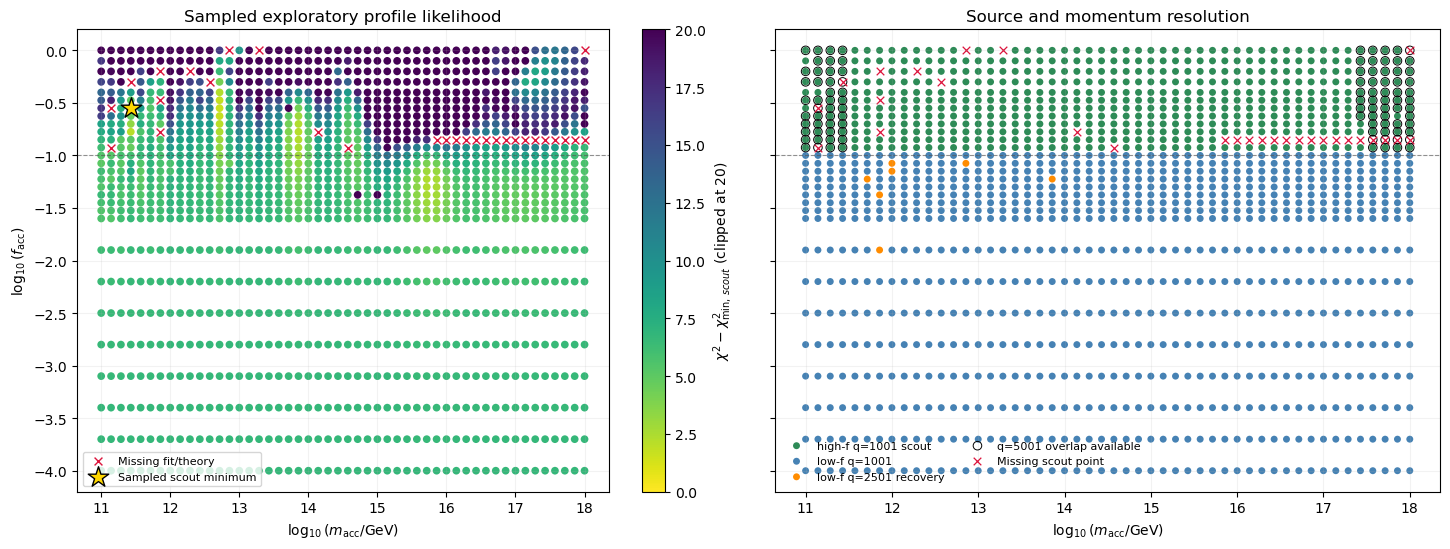

In [4]:
fig_sampled, axes = plt.subplots(1, 2, figsize=(14.6, 5.6), sharex=True, sharey=True)
scatter = axes[0].scatter(
    completed['log10m_acc'], completed['log10f_acc'],
    c=np.clip(completed['delta_chi2_from_scout_minimum'], 0, 20),
    cmap='viridis_r', s=31, edgecolor='none', rasterized=True,
)
fig_sampled.colorbar(
    scatter, ax=axes[0],
    label=r'$\chi^2-\chi^2_{\min,\,scout}$ (clipped at 20)',
)
axes[0].scatter(
    missing['log10m_acc'], missing['log10f_acc'], marker='x', s=32,
    color='crimson', linewidth=1.0, label='Missing fit/theory', zorder=5,
)
axes[0].scatter(
    [best['log10m_acc']], [best['log10f_acc']], marker='*', s=240,
    color='gold', edgecolor='black', label='Sampled scout minimum', zorder=6,
)
axes[0].set_title('Sampled exploratory profile likelihood')
axes[0].legend(frameon=True, fontsize=8)

source_styles = {
    'low_q1001': ('steelblue', 'low-f q=1001'),
    'low_q2501_recovery': ('darkorange', 'low-f q=2501 recovery'),
    'high_q1001_scout': ('seagreen', 'high-f q=1001 scout'),
}
for label, group in completed.groupby('source_label'):
    color, legend_label = source_styles.get(label, ('gray', label))
    axes[1].scatter(
        group['log10m_acc'], group['log10f_acc'], s=25, color=color,
        label=legend_label, edgecolor='none', rasterized=True,
    )
q5001_available = all_results[
    (all_results['source_label'] == 'high_q5001')
    & all_results['chi2_one_loop'].notna()
]
axes[1].scatter(
    q5001_available['log10m_acc'], q5001_available['log10f_acc'],
    facecolors='none', edgecolors='black', s=38, linewidth=0.7,
    label='q=5001 overlap available',
)
axes[1].scatter(
    missing['log10m_acc'], missing['log10f_acc'], marker='x', s=30,
    color='crimson', linewidth=0.9, label='Missing scout point',
)
axes[1].set_title('Source and momentum resolution')
axes[1].legend(frameon=False, fontsize=8, ncol=2)
for axis in axes:
    axis.axhline(-1.0, color='0.3', ls='--', lw=0.8, alpha=0.6)
    axis.set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
    axis.grid(alpha=0.16)
axes[0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
fig_sampled.tight_layout()
plt.show()

## Exploratory contour map with explicit missing-cell masking

A linear scattered interpolator draws the surface. A nearest-neighbor availability mask is built from every expected coordinate. Dense pixels assigned to a missing expected point are masked, so failed simulations are not silently filled.

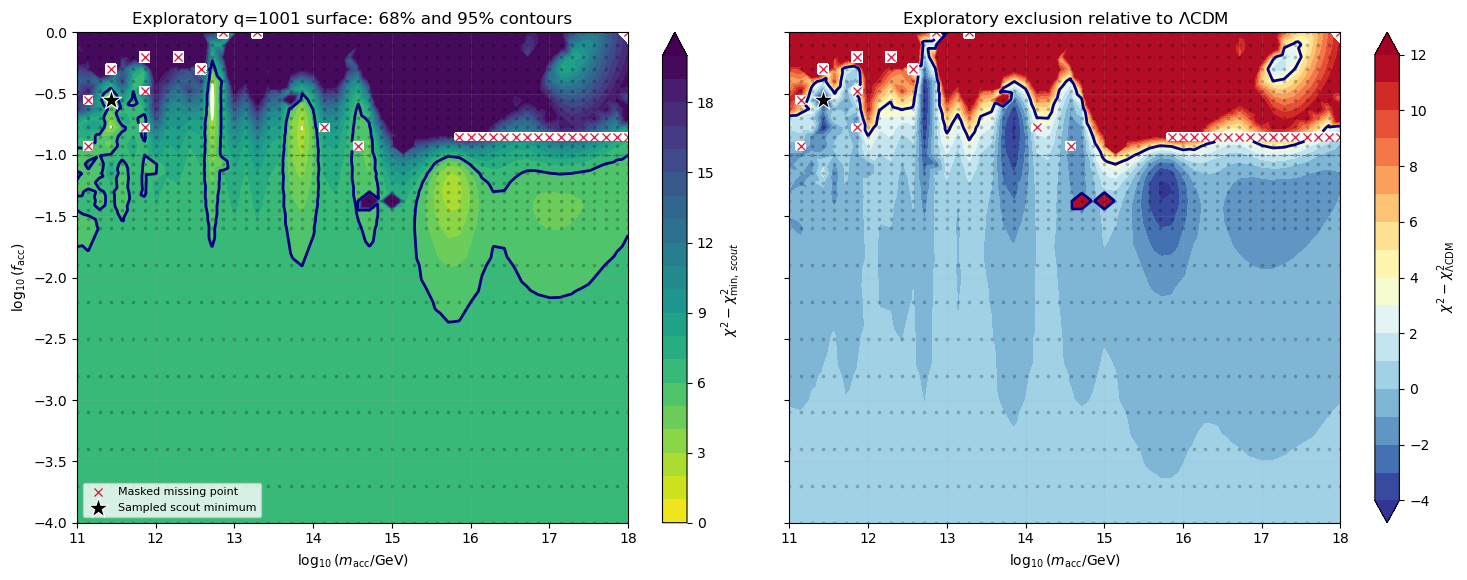

In [5]:
def masked_interpolated_surface(column, nx=620, ny=500):
    x_values = np.sort(expected['log10m_acc'].unique())
    y_values = np.sort(expected['log10f_acc'].unique())
    x_step = float(np.median(np.diff(x_values)))
    y_step = float(np.median(np.diff(y_values)))
    x_dense = np.linspace(x_values.min(), x_values.max(), nx)
    y_dense = np.linspace(y_values.min(), y_values.max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)

    sampled_coordinates = np.column_stack([
        completed['log10m_acc'] / x_step,
        completed['log10f_acc'] / y_step,
    ])
    dense_coordinates = np.column_stack([
        xx.ravel() / x_step, yy.ravel() / y_step,
    ])
    interpolator = LinearNDInterpolator(
        sampled_coordinates, completed[column].to_numpy(dtype=float),
        fill_value=np.nan,
    )
    surface = interpolator(dense_coordinates).reshape(xx.shape)

    availability_table = expected[['coordinate_key', 'log10m_acc', 'log10f_acc']].merge(
        completed[['coordinate_key']].assign(available=1.0),
        on='coordinate_key', how='left', validate='one_to_one',
    )
    availability_table['available'] = availability_table['available'].fillna(0.0)
    expected_coordinates = np.column_stack([
        availability_table['log10m_acc'] / x_step,
        availability_table['log10f_acc'] / y_step,
    ])
    availability = NearestNDInterpolator(
        expected_coordinates, availability_table['available'].to_numpy(dtype=float),
    )(dense_coordinates).reshape(xx.shape)
    mask = (~np.isfinite(surface)) | (availability < 0.5)
    return x_dense, y_dense, np.ma.array(surface, mask=mask)

x_dense, y_dense, delta_min_surface = masked_interpolated_surface(
    'delta_chi2_from_scout_minimum'
)
_, _, delta_lcdm_surface = masked_interpolated_surface('delta_chi2_vs_lcdm')

fig_maps, axes = plt.subplots(1, 2, figsize=(15.0, 5.9), sharex=True, sharey=True)
levels_left = np.linspace(0, min(20, float(np.nanmax(delta_min_surface))), 21)
filled_left = axes[0].contourf(
    x_dense, y_dense, np.clip(delta_min_surface, 0, 20),
    levels=levels_left, cmap='viridis_r', extend='max',
)
axes[0].contour(
    x_dense, y_dense, delta_min_surface,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=['white', 'navy'], linewidths=[1.4, 2.0],
)
fig_maps.colorbar(
    filled_left, ax=axes[0], label=r'$\chi^2-\chi^2_{\min,\,scout}$',
)
axes[0].set_title(r'Exploratory q=1001 surface: 68% and 95% contours')

filled_right = axes[1].contourf(
    x_dense, y_dense, np.clip(delta_lcdm_surface, -4, 12),
    levels=np.linspace(-4, 12, 17), cmap='RdYlBu_r', extend='both',
)
axes[1].contour(
    x_dense, y_dense, delta_lcdm_surface,
    levels=[EXCLUSION_DELTA_CHI2], colors='navy', linewidths=2.0,
)
fig_maps.colorbar(
    filled_right, ax=axes[1], label=r'$\chi^2-\chi^2_{\Lambda\mathrm{CDM}}$',
)
axes[1].set_title(r'Exploratory exclusion relative to $\Lambda$CDM')

for axis in axes:
    axis.scatter(
        completed['log10m_acc'], completed['log10f_acc'],
        s=3, color='black', alpha=0.16, rasterized=True,
    )
    axis.scatter(
        missing['log10m_acc'], missing['log10f_acc'], marker='x',
        s=34, color='crimson', linewidth=0.9, label='Masked missing point',
    )
    axis.scatter(
        [best['log10m_acc']], [best['log10f_acc']], marker='*', s=230,
        color='black', edgecolor='white', linewidth=0.8,
        label='Sampled scout minimum', zorder=6,
    )
    axis.axhline(-1.0, color='0.25', ls='--', lw=0.8, alpha=0.55)
    axis.set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
    axis.grid(alpha=0.12)
axes[0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
axes[0].legend(frameon=True, fontsize=8, loc='best')
fig_maps.tight_layout()
plt.show()

## Direct q=1001 versus q=5001 overlap

The absolute shift `chi2(q=5001)-chi2(q=1001)` measures the total numerical effect on the fit. The shape shift subtracts the minimum within the same overlap subset at each resolution before taking the difference. This removes a constant likelihood offset and isolates deformation of the sampled surface.

In [6]:
high_q1001 = all_results[
    (all_results['source_label'] == 'high_q1001_scout')
    & all_results['chi2_one_loop'].notna()
].copy()
high_q5001 = all_results[
    (all_results['source_label'] == 'high_q5001')
    & all_results['chi2_one_loop'].notna()
].copy()

overlap = high_q1001.merge(
    high_q5001, on='coordinate_key', how='inner',
    suffixes=('_q1001', '_q5001'), validate='one_to_one',
)
overlap['log10m_acc'] = overlap['log10m_acc_q1001']
overlap['log10f_acc'] = overlap['log10f_acc_q1001']
overlap['delta_chi2_q5001_minus_q1001'] = (
    overlap['chi2_one_loop_q5001'] - overlap['chi2_one_loop_q1001']
)
overlap['relative_chi2_q1001'] = (
    overlap['chi2_one_loop_q1001'] - overlap['chi2_one_loop_q1001'].min()
)
overlap['relative_chi2_q5001'] = (
    overlap['chi2_one_loop_q5001'] - overlap['chi2_one_loop_q5001'].min()
)
overlap['shape_shift_q5001_minus_q1001'] = (
    overlap['relative_chi2_q5001'] - overlap['relative_chi2_q1001']
)
overlap['absolute_chi2_shift'] = overlap['delta_chi2_q5001_minus_q1001'].abs()
overlap['absolute_shape_shift'] = overlap['shape_shift_q5001_minus_q1001'].abs()
for threshold, label in [(DELTA_CHI2_68_2D, '68pct'), (DELTA_CHI2_95_2D, '95pct')]:
    overlap[f'inside_{label}_q1001'] = overlap['relative_chi2_q1001'] <= threshold
    overlap[f'inside_{label}_q5001'] = overlap['relative_chi2_q5001'] <= threshold
    overlap[f'classification_changed_{label}'] = (
        overlap[f'inside_{label}_q1001'] != overlap[f'inside_{label}_q5001']
    )

if overlap.empty:
    raise RuntimeError('No completed q=1001/q=5001 overlap points were found.')
rank = spearmanr(overlap['chi2_one_loop_q1001'], overlap['chi2_one_loop_q5001'])
shift = overlap['delta_chi2_q5001_minus_q1001']
shape_shift = overlap['shape_shift_q5001_minus_q1001']
cross_refit_candidates = overlap.sort_values(
    [
        'classification_changed_95pct',
        'classification_changed_68pct',
        'absolute_shape_shift',
        'absolute_chi2_shift',
    ],
    ascending=[False, False, False, False],
).copy()
overlap_summary = pd.Series({
    'overlap points': len(overlap),
    'mean signed chi2 shift': float(shift.mean()),
    'median signed chi2 shift': float(shift.median()),
    'mean |chi2 shift|': float(shift.abs().mean()),
    'RMS chi2 shift': float(np.sqrt(np.mean(shift**2))),
    'maximum |chi2 shift|': float(shift.abs().max()),
    'RMS shape shift': float(np.sqrt(np.mean(shape_shift**2))),
    'maximum |shape shift|': float(shape_shift.abs().max()),
    'Spearman rank correlation': float(rank.statistic),
    'changed 68% classifications': int(overlap['classification_changed_68pct'].sum()),
    'changed 95% classifications': int(overlap['classification_changed_95pct'].sum()),
})
display(overlap_summary.to_frame('value'))
display(cross_refit_candidates[[
    'point_id_q1001', 'log10m_acc', 'log10f_acc',
    'chi2_one_loop_q1001', 'chi2_one_loop_q5001',
    'delta_chi2_q5001_minus_q1001',
    'shape_shift_q5001_minus_q1001',
    'classification_changed_68pct', 'classification_changed_95pct',
]].head(30))
display(overlap.nlargest(20, 'delta_chi2_q5001_minus_q1001', keep='all')[[
    'point_id_q1001', 'log10m_acc', 'log10f_acc',
    'chi2_one_loop_q1001', 'chi2_one_loop_q5001',
    'delta_chi2_q5001_minus_q1001', 'shape_shift_q5001_minus_q1001',
]])
display(overlap.nsmallest(20, 'delta_chi2_q5001_minus_q1001', keep='all')[[
    'point_id_q1001', 'log10m_acc', 'log10f_acc',
    'chi2_one_loop_q1001', 'chi2_one_loop_q5001',
    'delta_chi2_q5001_minus_q1001', 'shape_shift_q5001_minus_q1001',
]])

,value
overlap points,91.000000
mean signed chi2 shift,-1.198016
median signed chi2 shift,-0.140617
mean |chi2 shift|,2.577584
RMS chi2 shift,5.330976
maximum |chi2 shift|,28.869897
RMS shape shift,7.908486
maximum |shape shift|,33.635109
Spearman rank correlation,0.845819
changed 68% classifications,12.000000


,point_id_q1001,log10m_acc,log10f_acc,chi2_one_loop_q1001,chi2_one_loop_q5001,delta_chi2_q5001_minus_q1001,shape_shift_q5001_minus_q1001,classification_changed_68pct,classification_changed_95pct
20,accdm_logm11p2857142857143_logfm0p775,11.285714,-0.775,195.324249,193.056336,-2.267912,-7.033124,True,True
11,accdm_logm11p1428571428571_logfm0p7,11.142857,-0.700,194.328630,192.674684,-1.653946,-6.419158,True,True
21,accdm_logm11p2857142857143_logfm0p7,11.285714,-0.700,193.946192,192.444397,-1.501795,-6.267007,True,True
9,accdm_logm11p1428571428571_logfm0p85,11.142857,-0.850,193.813346,193.074131,-0.739215,-5.504426,True,True
0,accdm_logm11_logfm0p925,11.000000,-0.925,192.750218,192.471327,-0.278891,-5.044102,True,True
71,accdm_logm17p8571428571429_logfm0p925,17.857143,-0.925,193.625142,193.554528,-0.070613,-4.835825,True,True
81,accdm_logm18_logfm0p925,18.000000,-0.925,193.077786,193.015922,-0.061864,-4.827075,True,True
39,accdm_logm11p4285714285714_logfm0p1,11.428571,-0.100,209.451339,197.209504,-12.241835,-17.007047,False,True
12,accdm_logm11p1428571428571_logfm0p625,11.142857,-0.625,199.346482,194.987325,-4.359158,-9.124369,False,True
22,accdm_logm11p2857142857143_logfm0p625,11.285714,-0.625,196.216101,194.816806,-1.399295,-6.164507,False,True


,point_id_q1001,log10m_acc,log10f_acc,chi2_one_loop_q1001,chi2_one_loop_q5001,delta_chi2_q5001_minus_q1001,shape_shift_q5001_minus_q1001
4,accdm_logm11_logfm0p625,11.000000,-0.625,203.043817,213.753759,10.709942,5.944730
61,accdm_logm17p7142857142857_logfm0p775,17.714286,-0.775,198.552928,208.177518,9.624589,4.859378
35,accdm_logm11p4285714285714_logfm0p55,11.428571,-0.550,186.570638,195.918184,9.347546,4.582335
28,accdm_logm11p2857142857143_logfm0p1,11.285714,-0.100,206.725432,215.922126,9.196694,4.431482
36,accdm_logm11p4285714285714_logfm0p475,11.428571,-0.475,191.493057,195.945773,4.452716,-0.312496
34,accdm_logm11p4285714285714_logfm0p625,11.428571,-0.625,191.286512,195.035713,3.749201,-1.016011
37,accdm_logm11p4285714285714_logfm0p4,11.428571,-0.400,195.322512,198.308348,2.985836,-1.779375
33,accdm_logm11p4285714285714_logfm0p7,11.428571,-0.700,189.915208,192.722290,2.807082,-1.958130
32,accdm_logm11p4285714285714_logfm0p775,11.428571,-0.775,188.715192,191.335849,2.620657,-2.144555
19,accdm_logm11p2857142857143_logfm0p85,11.285714,-0.850,191.753644,193.681921,1.928276,-2.836935


,point_id_q1001,log10m_acc,log10f_acc,chi2_one_loop_q1001,chi2_one_loop_q5001,delta_chi2_q5001_minus_q1001,shape_shift_q5001_minus_q1001
29,accdm_logm11p2857142857143_logf0,11.285714,0.000,228.092374,199.222477,-28.869897,-33.635109
17,accdm_logm11p1428571428571_logf0,11.142857,0.000,226.038899,209.350611,-16.688288,-21.453500
26,accdm_logm11p2857142857143_logfm0p3,11.285714,-0.300,215.828421,201.754772,-14.073650,-18.838861
27,accdm_logm11p2857142857143_logfm0p2,11.285714,-0.200,214.021673,201.728931,-12.292742,-17.057954
39,accdm_logm11p4285714285714_logfm0p1,11.428571,-0.100,209.451339,197.209504,-12.241835,-17.007047
38,accdm_logm11p4285714285714_logfm0p2,11.428571,-0.200,219.252750,207.960137,-11.292613,-16.057825
40,accdm_logm11p4285714285714_logf0,11.428571,0.000,210.113755,200.564114,-9.549642,-14.314853
84,accdm_logm18_logfm0p625,18.000000,-0.625,207.937775,198.542865,-9.394910,-14.160122
16,accdm_logm11p1428571428571_logfm0p1,11.142857,-0.100,213.644873,206.162256,-7.482618,-12.247829
7,accdm_logm11_logfm0p2,11.000000,-0.200,208.816145,201.844779,-6.971367,-11.736579


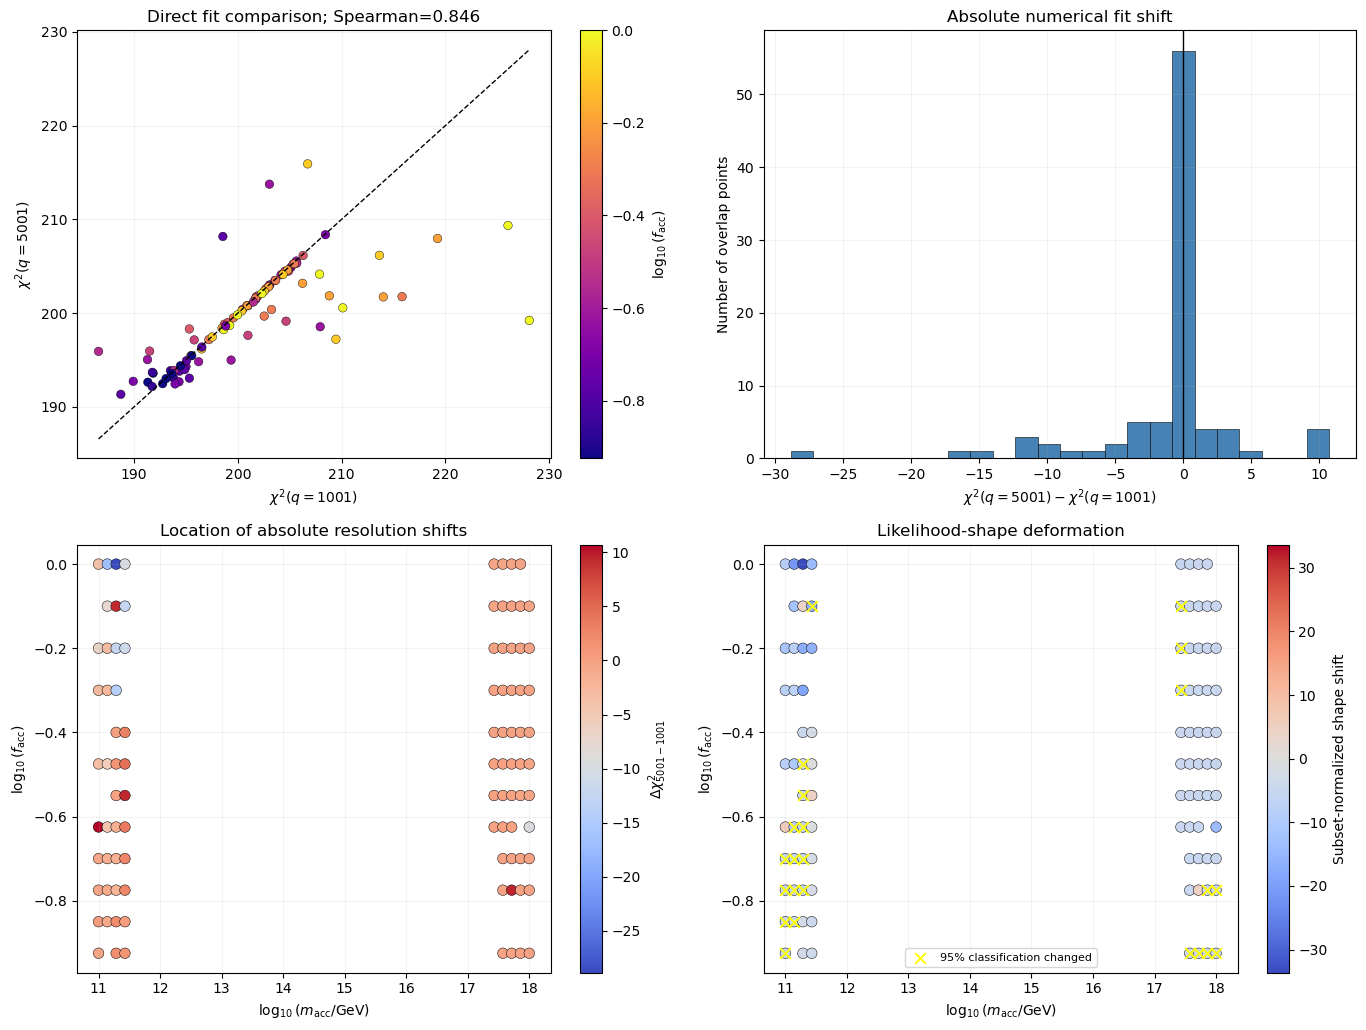

In [7]:
fig_overlap, axes = plt.subplots(2, 2, figsize=(13.8, 10.4))
color = overlap['log10f_acc']
points = axes[0, 0].scatter(
    overlap['chi2_one_loop_q1001'], overlap['chi2_one_loop_q5001'],
    c=color, cmap='plasma', s=38, edgecolor='black', linewidth=0.3,
)
lower = float(min(overlap['chi2_one_loop_q1001'].min(), overlap['chi2_one_loop_q5001'].min()))
upper = float(max(overlap['chi2_one_loop_q1001'].max(), overlap['chi2_one_loop_q5001'].max()))
axes[0, 0].plot([lower, upper], [lower, upper], color='black', ls='--', lw=1.0)
fig_overlap.colorbar(points, ax=axes[0, 0], label=r'$\log_{10}(f_{\rm acc})$')
axes[0, 0].set_xlabel(r'$\chi^2(q=1001)$')
axes[0, 0].set_ylabel(r'$\chi^2(q=5001)$')
axes[0, 0].set_title(f'Direct fit comparison; Spearman={rank.statistic:.3f}')

axes[0, 1].hist(
    overlap['delta_chi2_q5001_minus_q1001'], bins=24,
    color='steelblue', edgecolor='black', linewidth=0.4,
)
axes[0, 1].axvline(0, color='black', lw=1.0)
axes[0, 1].set_xlabel(r'$\chi^2(q=5001)-\chi^2(q=1001)$')
axes[0, 1].set_ylabel('Number of overlap points')
axes[0, 1].set_title('Absolute numerical fit shift')

absolute_map = axes[1, 0].scatter(
    overlap['log10m_acc'], overlap['log10f_acc'],
    c=overlap['delta_chi2_q5001_minus_q1001'], cmap='coolwarm',
    s=58, edgecolor='black', linewidth=0.35,
)
fig_overlap.colorbar(absolute_map, ax=axes[1, 0], label=r'$\Delta\chi^2_{5001-1001}$')
axes[1, 0].set_title('Location of absolute resolution shifts')
axes[1, 0].set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
axes[1, 0].set_ylabel(r'$\log_{10}(f_{\rm acc})$')

shape_limit = max(float(shape_shift.abs().max()), 1e-12)
shape_map = axes[1, 1].scatter(
    overlap['log10m_acc'], overlap['log10f_acc'],
    c=shape_shift, cmap='coolwarm', vmin=-shape_limit, vmax=shape_limit,
    s=58, edgecolor='black', linewidth=0.35,
)
fig_overlap.colorbar(shape_map, ax=axes[1, 1], label='Subset-normalized shape shift')
changed = overlap[overlap['classification_changed_95pct']]
axes[1, 1].scatter(
    changed['log10m_acc'], changed['log10f_acc'], marker='x', s=60,
    color='yellow', linewidth=1.4, label='95% classification changed',
)
axes[1, 1].set_title('Likelihood-shape deformation')
axes[1, 1].set_xlabel(r'$\log_{10}(m_{\rm acc}/\mathrm{GeV})$')
axes[1, 1].set_ylabel(r'$\log_{10}(f_{\rm acc})$')
if not changed.empty:
    axes[1, 1].legend(frameon=True, fontsize=8)
for axis in axes.ravel():
    axis.grid(alpha=0.16)
fig_overlap.tight_layout()
plt.show()

## Nuisance-parameter response to momentum resolution

Absolute nuisance shifts can be misleading because the numerical boxes have very different widths. The normalized shift below divides each parameter change by its fitted numerical-box width. This remains a numerical diagnostic, not a prior-based significance.

,points,median_absolute_shift,maximum_absolute_shift,median_normalized_box_shift,maximum_normalized_box_shift
parameter,,,,,
beta_ct,91,3.478231,1421.848829,1.999515e-03,3.297325
alpha_bias,91,0.005632,4.393205,3.519747e-04,0.274575
beta_bias,91,0.025023,6.564105,7.149377e-04,0.187546
beta_F,91,0.008230,0.566858,2.743479e-04,0.018895
log_alpha_F,91,0.001564,0.139435,1.280985e-04,0.011423
alpha_ct,91,0.000363,0.341834,5.154340e-07,0.001251


/tmp/ipykernel_861687/336548833.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(groups, labels=PARAMETER_NAMES, showfliers=True)


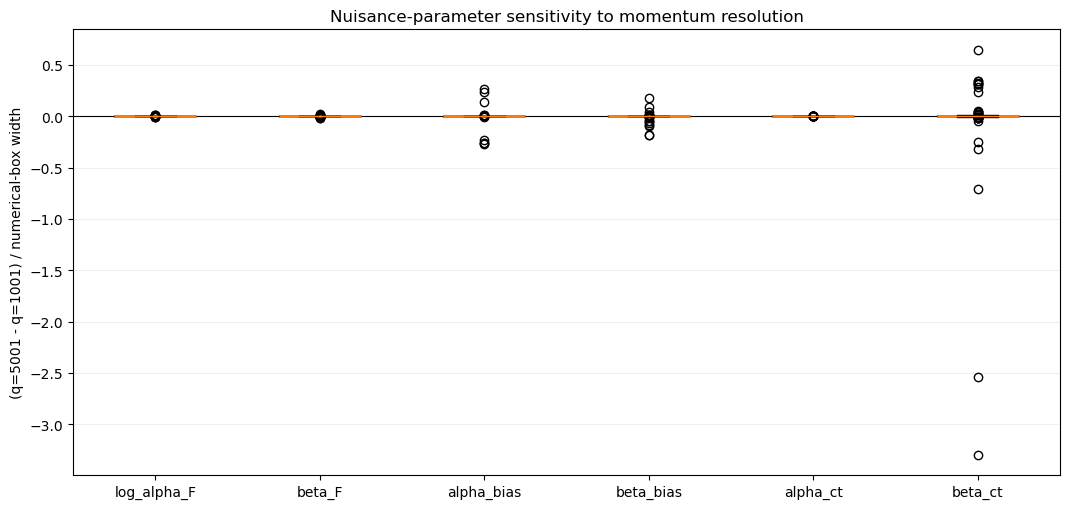

In [8]:
PARAMETER_NAMES = [
    'log_alpha_F', 'beta_F', 'alpha_bias',
    'beta_bias', 'alpha_ct', 'beta_ct',
]
parameter_shift_rows = []
for record in overlap.to_dict(orient='records'):
    for parameter in PARAMETER_NAMES:
        value_1001 = float(record[f'parameter_{parameter}_q1001'])
        value_5001 = float(record[f'parameter_{parameter}_q5001'])
        diagnostic = all_nuisance[
            (all_nuisance['coordinate_key'] == record['coordinate_key'])
            & (all_nuisance['source_label'] == 'high_q5001')
            & (all_nuisance['parameter'] == parameter)
        ]
        if diagnostic.empty:
            width = np.nan
        else:
            item = diagnostic.iloc[0]
            width = float(item['upper'] - item['lower'])
        parameter_shift_rows.append({
            'coordinate_key': record['coordinate_key'],
            'point_id': record['point_id_q1001'],
            'log10m_acc': record['log10m_acc'],
            'log10f_acc': record['log10f_acc'],
            'parameter': parameter,
            'value_q1001': value_1001,
            'value_q5001': value_5001,
            'absolute_shift': value_5001 - value_1001,
            'box_width': width,
            'normalized_box_shift': (value_5001 - value_1001) / width,
        })
parameter_shifts = pd.DataFrame(parameter_shift_rows)
parameter_summary = parameter_shifts.groupby('parameter').agg(
    points=('coordinate_key', 'nunique'),
    median_absolute_shift=('absolute_shift', lambda values: float(np.median(np.abs(values)))),
    maximum_absolute_shift=('absolute_shift', lambda values: float(np.max(np.abs(values)))),
    median_normalized_box_shift=('normalized_box_shift', lambda values: float(np.median(np.abs(values)))),
    maximum_normalized_box_shift=('normalized_box_shift', lambda values: float(np.max(np.abs(values)))),
).sort_values('maximum_normalized_box_shift', ascending=False)
display(parameter_summary)

fig_parameters, axis = plt.subplots(figsize=(10.8, 5.2))
groups = [
    parameter_shifts.loc[parameter_shifts['parameter'] == name, 'normalized_box_shift'].dropna()
    for name in PARAMETER_NAMES
]
axis.boxplot(groups, labels=PARAMETER_NAMES, showfliers=True)
axis.axhline(0, color='black', lw=0.8)
axis.set_ylabel('(q=5001 - q=1001) / numerical-box width')
axis.set_title('Nuisance-parameter sensitivity to momentum resolution')
axis.grid(axis='y', alpha=0.2)
fig_parameters.tight_layout()
plt.show()

## Save analysis products

In [9]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    completed.sort_values(['log10f_acc', 'log10m_acc']).to_csv(
        OUTPUT_DIR / 'full_scout_profile_likelihood.csv', index=False
    )
    missing.sort_values(['log10f_acc', 'log10m_acc']).to_csv(
        OUTPUT_DIR / 'full_scout_missing_points.csv', index=False
    )
    overlap.sort_values(['log10f_acc', 'log10m_acc']).to_csv(
        OUTPUT_DIR / 'highf_q1001_q5001_overlap.csv', index=False
    )
    cross_refit_candidates.to_csv(
        OUTPUT_DIR / 'highf_q1001_q5001_cross_refit_candidates.csv',
        index=False,
    )
    parameter_shifts.to_csv(
        OUTPUT_DIR / 'highf_q1001_q5001_parameter_shifts.csv', index=False
    )
    parameter_summary.to_csv(
        OUTPUT_DIR / 'highf_q1001_q5001_parameter_summary.csv'
    )
    summary = {
        'scope': 'exploratory_full_q1001_scout_with_explicit_missing_cells',
        'expected_point_count': int(len(expected)),
        'completed_scout_point_count': int(len(completed)),
        'missing_point_count': int(len(missing)),
        'sampled_best_point': {
            'point_id': str(best['expected_point_id']),
            'log10m_acc': float(best['log10m_acc']),
            'log10f_acc': float(best['log10f_acc']),
            'f_acc': float(10**best['log10f_acc']),
            'chi2_one_loop': float(best['chi2_one_loop']),
            'delta_chi2_vs_lcdm': float(best['delta_chi2_vs_lcdm']),
        },
        'lcdm_reference_chi2': float(LCDM_ONE_LOOP_CHI2),
        'q_overlap_summary': {
            key: (int(value) if key in {
                'overlap points', 'changed 68% classifications',
                'changed 95% classifications'
            } else float(value))
            for key, value in overlap_summary.items()
        },
        'provisional_reasons': [
            'high_fraction_q1001_not_numerically_converged',
            'missing_failed_theory_points_are_masked',
            'q5001_overlap_is_not_uniform_over_the_full_grid',
            'final_minimum_and_contours_require_targeted_q5001_or_q10001_validation',
        ],
    }
    (OUTPUT_DIR / 'full_scout_summary.json').write_text(
        json.dumps(summary, indent=2, sort_keys=True) + '\n', encoding='utf-8'
    )
    fig_sampled.savefig(
        OUTPUT_DIR / 'full_scout_sampled_likelihood_and_sources.png',
        dpi=220, bbox_inches='tight',
    )
    fig_maps.savefig(
        OUTPUT_DIR / 'full_scout_profile_likelihood_maps.png',
        dpi=220, bbox_inches='tight',
    )
    fig_overlap.savefig(
        OUTPUT_DIR / 'highf_q1001_q5001_overlap_diagnostics.png',
        dpi=220, bbox_inches='tight',
    )
    fig_parameters.savefig(
        OUTPUT_DIR / 'highf_q1001_q5001_nuisance_shifts.png',
        dpi=220, bbox_inches='tight',
    )
    print('Saved analysis products to:', OUTPUT_DIR)

Saved analysis products to: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_full_scout_q1001_q5001_v1


## Interpretation checklist

1. Quote only the discrete sampled scout minimum; contours are visual guidance.
2. Treat every high-fraction `q=1001` chi-square as exploratory.
3. A nearly constant `q=5001-q=1001` offset changes absolute goodness of fit but not contour topology; the subset-normalized shape shift measures the latter.
4. If the numerical shape shift is comparable to 2.30 or 5.991, the corresponding one- or two-sigma boundary is not stable.
5. Do not infer smooth behavior through red-cross or masked cells. Recover only failed points close to the sampled minimum or candidate contours.
6. Validate the final minimum and representative contour anchors with `q=5001` or `q=10001`.